In [1]:
!ls /kaggle/input/datasets/pranavpatil00/bcc-skincancer/BCC_skincancer

Test  Train


In [6]:
import os
import glob
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, utils
from PIL import Image
import matplotlib.pyplot as plt

# 1. CONFIGURATION
class Config:
    TRAIN_DIR   = "/kaggle/input/datasets/pranavpatil00/bcc-skincancer/BCC_skincancer/Train"
    OUTPUT_DIR  = "/kaggle/working/dcgan_output"
    IMG_SIZE    = 192
    CHANNELS    = 3
    LATENT_DIM  = 128
    BATCH_SIZE  = 32
    EPOCHS      = 500     # Adjusted for faster steps
    LR          = 0.0002
    BETA1       = 0.5     # Standard for DCGAN
    BASE_FEAT   = 64      # Filter multiplier

cfg = Config()
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [3]:
print(device)

cuda


In [3]:

# 2. DATASET
class BCCDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.file_list = []
        for ext in ['*.jpg', '*.jpeg', '*.png']:
            self.file_list.extend(glob.glob(os.path.join(root_dir, '**', ext), recursive=True))
        self.transform = transform
    def __len__(self): return len(self.file_list)
    def __getitem__(self, idx):
        img = Image.open(self.file_list[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img

transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3) # Scales to [-1, 1]
])

# 3. MODELS
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [4]:

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Start: Latent Vector (128, 1, 1) -> (512, 6, 6)
            nn.ConvTranspose2d(cfg.LATENT_DIM, cfg.BASE_FEAT * 8, 6, 1, 0, bias=False),
            nn.BatchNorm2d(cfg.BASE_FEAT * 8),
            nn.ReLU(True),
            # (256, 12, 12)
            nn.ConvTranspose2d(cfg.BASE_FEAT * 8, cfg.BASE_FEAT * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(cfg.BASE_FEAT * 4),
            nn.ReLU(True),
            # (128, 24, 24)
            nn.ConvTranspose2d(cfg.BASE_FEAT * 4, cfg.BASE_FEAT * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(cfg.BASE_FEAT * 2),
            nn.ReLU(True),
            # (64, 48, 48)
            nn.ConvTranspose2d(cfg.BASE_FEAT * 2, cfg.BASE_FEAT, 4, 2, 1, bias=False),
            nn.BatchNorm2d(cfg.BASE_FEAT),
            nn.ReLU(True),
            # (32, 96, 96)
            nn.ConvTranspose2d(cfg.BASE_FEAT, cfg.BASE_FEAT // 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(cfg.BASE_FEAT // 2),
            nn.ReLU(True),
            # Output: (3, 192, 192)
            nn.ConvTranspose2d(cfg.BASE_FEAT // 2, cfg.CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, x): return self.main(x)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input 192x192
            nn.Conv2d(cfg.CHANNELS, cfg.BASE_FEAT, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 96x96
            nn.Conv2d(cfg.BASE_FEAT, cfg.BASE_FEAT * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(cfg.BASE_FEAT * 2),
            nn.Dropout(0.3),
            nn.LeakyReLU(0.2, inplace=True),
            # 48x48
            nn.Conv2d(cfg.BASE_FEAT * 2, cfg.BASE_FEAT * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(cfg.BASE_FEAT * 4),
            nn.Dropout(0.3),
            nn.LeakyReLU(0.2, inplace=True),
            # 24x24
            nn.Conv2d(cfg.BASE_FEAT * 4, cfg.BASE_FEAT * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(cfg.BASE_FEAT * 8),
            nn.Dropout(0.3),
            nn.LeakyReLU(0.2, inplace=True),
            # 12x12
            nn.Conv2d(cfg.BASE_FEAT * 8, cfg.BASE_FEAT * 16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(cfg.BASE_FEAT * 16),
            nn.Dropout(0.3),
            nn.LeakyReLU(0.2, inplace=True),
            # 6x6 -> 1 (Decision)
            nn.Conv2d(cfg.BASE_FEAT * 16, 1, 6, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x): return self.main(x).view(-1)


Starting DCGAN training on 376 images...
Epoch [50/500] Loss_D: 1.1814 Loss_G: 3.8122


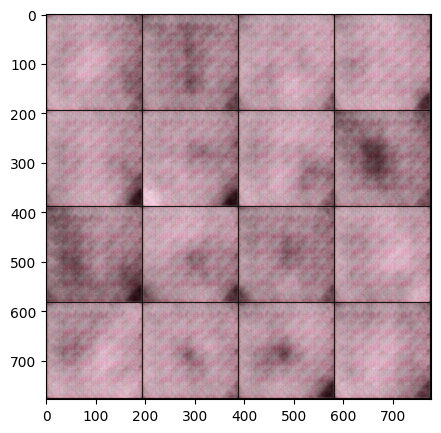

Epoch [100/500] Loss_D: 1.2591 Loss_G: 2.8534


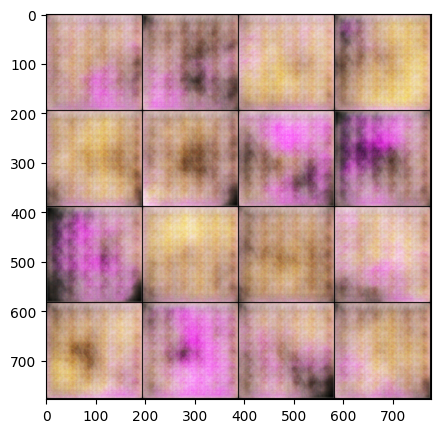

Epoch [150/500] Loss_D: 1.0900 Loss_G: 2.7166


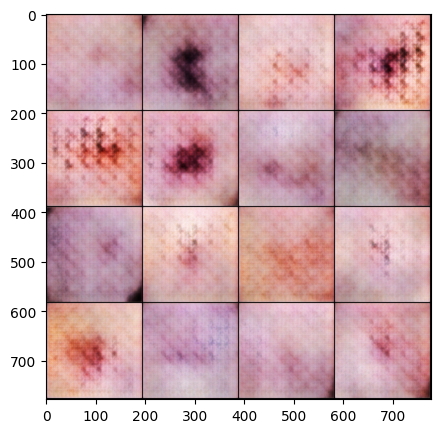

Epoch [200/500] Loss_D: 1.0991 Loss_G: 1.5349


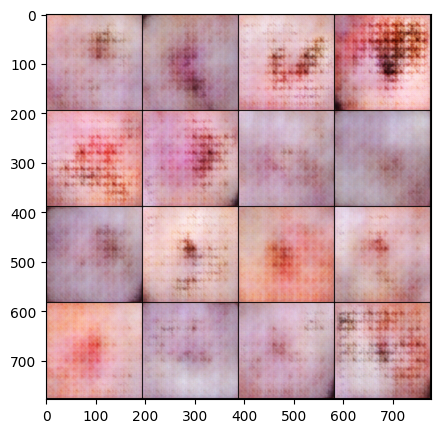

Epoch [250/500] Loss_D: 1.4898 Loss_G: 1.1699


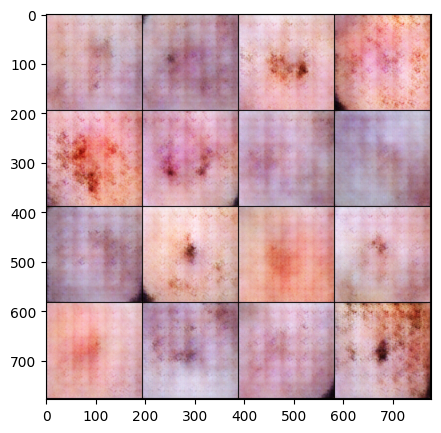

Epoch [300/500] Loss_D: 0.9430 Loss_G: 1.9710


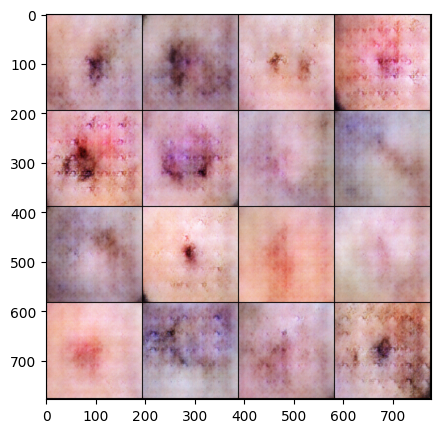

Epoch [350/500] Loss_D: 1.1645 Loss_G: 2.8573


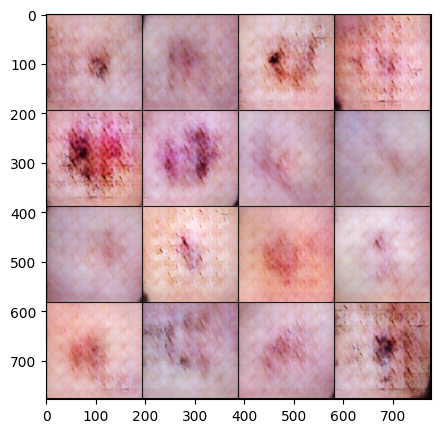

Epoch [400/500] Loss_D: 1.0269 Loss_G: 1.8475


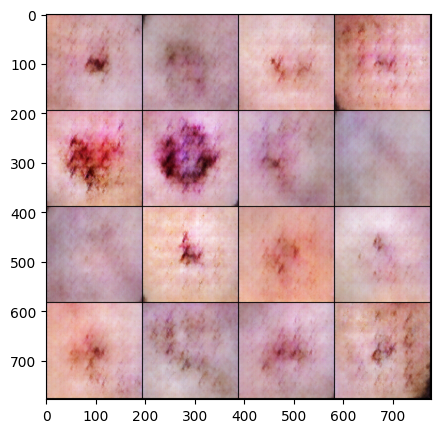

Epoch [450/500] Loss_D: 0.9735 Loss_G: 2.1114


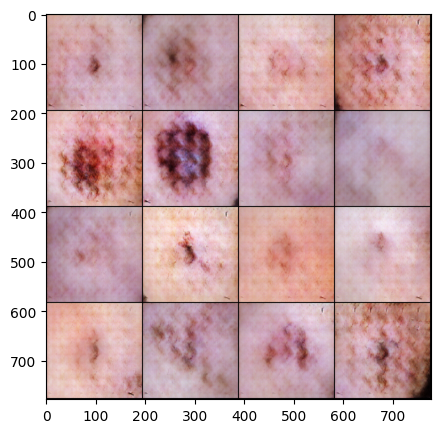

Epoch [500/500] Loss_D: 1.0257 Loss_G: 3.7342


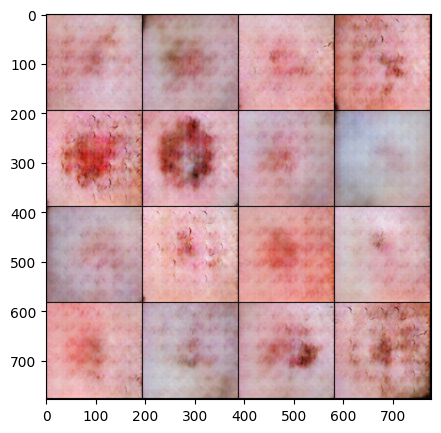

Saving 282 synthetic images to /kaggle/working/synthetic_bcc...


In [7]:


# 4. TRAINING EXECUTION
def train_dcgan():
    dataset = BCCDataset(cfg.TRAIN_DIR, transform=transform)
    dataloader = DataLoader(dataset, batch_size=cfg.BATCH_SIZE, shuffle=True, drop_last=True)
    history = {'G': [], 'D': []}
    netG = Generator().to(device)
    netD = Discriminator().to(device)
    netG.apply(weights_init)
    netD.apply(weights_init)

    criterion = nn.BCELoss()
    optimizerD = optim.Adam(netD.parameters(), lr=cfg.LR, betas=(cfg.BETA1, 0.999))
    optimizerG = optim.Adam(netG.parameters(), lr=cfg.LR, betas=(cfg.BETA1, 0.999))

    fixed_noise = torch.randn(16, cfg.LATENT_DIM, 1, 1).to(device)
    
    print(f"Starting DCGAN training on {len(dataset)} images...")

    for epoch in range(cfg.EPOCHS):
        g_loss_epoch = 0.0
        d_loss_epoch = 0.0
        num_batches = 0
        for i, real_images in enumerate(dataloader):
            b_size = real_images.size(0)
            real_images = real_images.to(device)
            
            # --- Update Discriminator ---
            netD.zero_grad()
            # Real images
            label = torch.full((b_size,), 0.9, device=device) # Real = 1
            output = netD(real_images)
            errD_real = criterion(output, label)
            errD_real.backward()

            # Fake images
            noise = torch.randn(b_size, cfg.LATENT_DIM, 1, 1).to(device)
            fake = netG(noise)
            label.fill_(0.1) # Fake = 0
            output = netD(fake.detach())
            errD_fake = criterion(output, label)
            errD_fake.backward()
            optimizerD.step()
            d_loss_history = (errD_real + errD_fake).item()

            # --- Update Generator ---
            netG.zero_grad()
            label.fill_(1.0) # G wants D to think fakes are real
            output = netD(fake)
            errG = criterion(output, label)
            errG.backward()
            optimizerG.step()
            
            g_loss_history = errG.item()
            g_loss_epoch += g_loss_history
            d_loss_epoch += d_loss_history
            num_batches += 1

        history['G'].append(g_loss_epoch / num_batches)
        history['D'].append(d_loss_epoch / num_batches)

        if (epoch + 1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{cfg.EPOCHS}] Loss_D: {errD_real+errD_fake:.4f} Loss_G: {errG:.4f}")
            with torch.no_grad():
                samples = netG(fixed_noise).detach().cpu()
                grid = utils.make_grid(samples, normalize=True, nrow=4)
                plt.figure(figsize=(5,5))
                plt.imshow(grid.permute(1, 2, 0))
                plt.show()

    return netG, dataset, history

# 5. AUGMENTATION (75% RATIO)
def generate_augmented_data(netG, dataset):
    n_fake = int(len(dataset) * 0.75)
    save_path = "/kaggle/working/synthetic_bcc"
    os.makedirs(save_path, exist_ok=True)
    netG.eval()
    
    print(f"Saving {n_fake} synthetic images to {save_path}...")
    with torch.no_grad():
        for i in range(n_fake):
            noise = torch.randn(1, cfg.LATENT_DIM, 1, 1).to(device)
            img = netG(noise).cpu().squeeze(0)
            img = (img + 1) / 2 # Normalize to [0, 1]
            img = transforms.ToPILImage()(img)
            img.save(os.path.join(save_path, f"fake_bcc_{i:04d}.png"))

if __name__ == "__main__":
    trained_gen, bcc_data, history = train_dcgan()
    generate_augmented_data(trained_gen, bcc_data)

In [28]:
import torch.nn.utils.spectral_norm as spectral_norm

class SelfAttention(nn.Module):
    """Self-Attention layer as proposed by Zhang et al. (2019)"""
    def __init__(self, in_channels):
        super(SelfAttention, self).__init__()
        self.query = nn.Conv2d(in_channels, in_channels // 8, 1)
        self.key   = nn.Conv2d(in_channels, in_channels // 8, 1)
        self.value = nn.Conv2d(in_channels, in_channels, 1)
        self.gamma = nn.Parameter(torch.zeros(1)) 
        self.attn_map = None

    def forward(self, x):
        B, C, H, W = x.size()
        # Query: [B, C/8, N]
        q = self.query(x).view(B, -1, H * W).permute(0, 2, 1)
        # Key: [B, C/8, N]
        k = self.key(x).view(B, -1, H * W)
        # Attention Map: [B, N, N]
        attn = torch.softmax(torch.bmm(q, k), dim=-1)
        # Value: [B, C, N]
        v = self.value(x).view(B, -1, H * W)
        
        out = torch.bmm(v, attn.permute(0, 2, 1)).view(B, C, H, W)
        self.attn_map = attn
        return self.gamma * out + x

class ProposedGenerator(nn.Module):
    def __init__(self):
        super(ProposedGenerator, self).__init__()
        self.main = nn.Sequential(
            # (128, 1, 1) -> (512, 6, 6)
            nn.ConvTranspose2d(cfg.LATENT_DIM, cfg.BASE_FEAT * 8, 6, 1, 0, bias=False),
            nn.BatchNorm2d(cfg.BASE_FEAT * 8), nn.ReLU(True),
            # (256, 12, 12)
            nn.ConvTranspose2d(cfg.BASE_FEAT * 8, cfg.BASE_FEAT * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(cfg.BASE_FEAT * 4), nn.ReLU(True),
            # (128, 24, 24)
            nn.ConvTranspose2d(cfg.BASE_FEAT * 4, cfg.BASE_FEAT * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(cfg.BASE_FEAT * 2), nn.ReLU(True),
            # (64, 48, 48)
            nn.ConvTranspose2d(cfg.BASE_FEAT * 2, cfg.BASE_FEAT, 4, 2, 1, bias=False),
            SelfAttention(cfg.BASE_FEAT), # SELF ATTENTION AT 48x48
            nn.BatchNorm2d(cfg.BASE_FEAT), nn.ReLU(True),
            # (32, 96, 96)
            nn.ConvTranspose2d(cfg.BASE_FEAT, cfg.BASE_FEAT // 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(cfg.BASE_FEAT // 2), nn.ReLU(True),
            # Output: (3, 192, 192)
            nn.ConvTranspose2d(cfg.BASE_FEAT // 2, cfg.CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, x): return self.main(x)


In [34]:

class ProposedDiscriminator(nn.Module):
    def __init__(self):
        super(ProposedDiscriminator, self).__init__()
        self.main = nn.Sequential(
            spectral_norm(nn.Conv2d(cfg.CHANNELS, cfg.BASE_FEAT, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Conv2d(cfg.BASE_FEAT, cfg.BASE_FEAT * 2, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Conv2d(cfg.BASE_FEAT * 2, cfg.BASE_FEAT * 4, 4, 2, 1, bias=False)),
            SelfAttention(cfg.BASE_FEAT * 4), # SELF ATTENTION AT 48x48
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Conv2d(cfg.BASE_FEAT * 4, cfg.BASE_FEAT * 8, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            spectral_norm(nn.Conv2d(cfg.BASE_FEAT * 8, cfg.BASE_FEAT * 16, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(cfg.BASE_FEAT * 16, 1, 6, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x): return self.main(x).view(-1)

In [8]:
import torch.nn.functional as F

def feature_matching_loss(real_feats, fake_feats):

    loss = 0

    for real_f, fake_f in zip(real_feats, fake_feats):

        # Global Average Pooling
        real_mean = real_f.mean(dim=[2, 3])
        fake_mean = fake_f.mean(dim=[2, 3])

        loss += F.l1_loss(fake_mean, real_mean)

    return loss

In [35]:
def train_proposed_dcgan():
    dataset = BCCDataset(cfg.TRAIN_DIR, transform=transform)
    dataloader = DataLoader(dataset, batch_size=cfg.BATCH_SIZE, shuffle=True, drop_last=True)
    n_history = {'G': [], 'D': []}
    netG = ProposedGenerator().to(device)
    netD = ProposedDiscriminator().to(device)
    netG.apply(weights_init)
    netD.apply(weights_init)

    criterion = nn.BCELoss()
    optimizerD = optim.Adam(netD.parameters(), lr=cfg.LR, betas=(cfg.BETA1, 0.999))
    optimizerG = optim.Adam(netG.parameters(), lr=cfg.LR, betas=(cfg.BETA1, 0.999))

    fixed_noise = torch.randn(16, cfg.LATENT_DIM, 1, 1).to(device)
    
    print(f"Starting DCGAN training on {len(dataset)} images...")

    for epoch in range(cfg.EPOCHS):
        g_loss_epoch = 0.0
        d_loss_epoch = 0.0
        num_batches = 0
        for i, real_images in enumerate(dataloader):
            b_size = real_images.size(0)
            real_images = real_images.to(device)
            
            # --- Update Discriminator ---
            netD.zero_grad()
            # Real images
            label = torch.full((b_size,), 0.9, device=device) # Real = 1
            output = netD(real_images)
            errD_real = criterion(output, label)
            errD_real.backward()

            # Fake images
            noise = torch.randn(b_size, cfg.LATENT_DIM, 1, 1).to(device)
            fake = netG(noise)
            label.fill_(0.1) # Fake = 0
            output = netD(fake.detach())
            errD_fake = criterion(output, label)
            errD_fake.backward()
            optimizerD.step()

            d_loss_history = (errD_real + errD_fake).item()

            # --- Update Generator ---
            netG.zero_grad()
            label.fill_(1.0) # G wants D to think fakes are real
            output = netD(fake)
            errG = criterion(output, label)
            errG.backward()
            optimizerG.step()
            
            g_loss_history = errG.item()

            g_loss_epoch += g_loss_history
            d_loss_epoch += d_loss_history
            num_batches += 1
        
        n_history['G'].append(g_loss_epoch / num_batches)
        n_history['D'].append(d_loss_epoch / num_batches)
        if (epoch + 1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{cfg.EPOCHS}] Loss_D: {errD_real+errD_fake:.4f} Loss_G: {errG:.4f}")
            with torch.no_grad():
                samples = netG(fixed_noise).detach().cpu()
                grid = utils.make_grid(samples, normalize=True, nrow=4)
                plt.figure(figsize=(5,5))
                plt.imshow(grid.permute(1, 2, 0))
                plt.show()

    return netG, dataset, n_history

Starting DCGAN training on 376 images...
Epoch [50/500] Loss_D: 1.0983 Loss_G: 1.1369


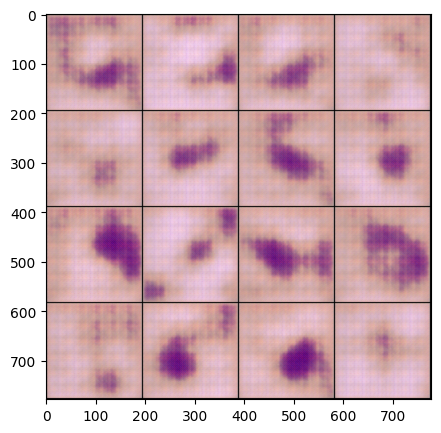

Epoch [100/500] Loss_D: 1.4639 Loss_G: 0.6839


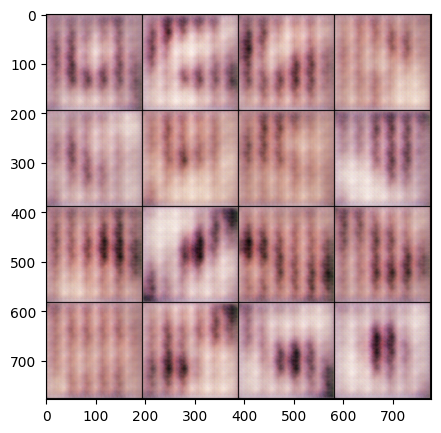

Epoch [150/500] Loss_D: 1.2855 Loss_G: 0.8846


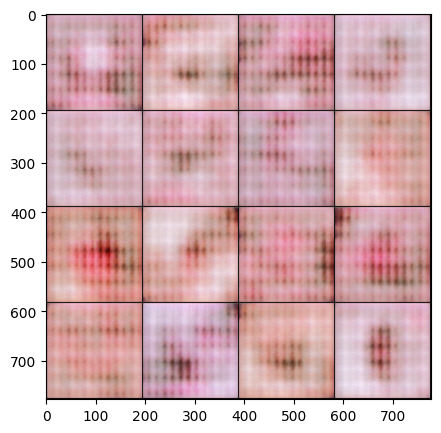

Epoch [200/500] Loss_D: 1.3018 Loss_G: 0.8058


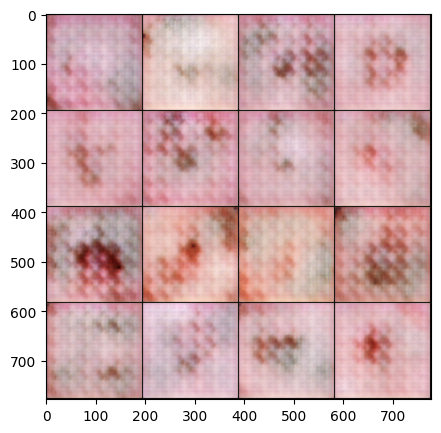

Epoch [250/500] Loss_D: 1.2543 Loss_G: 0.9729


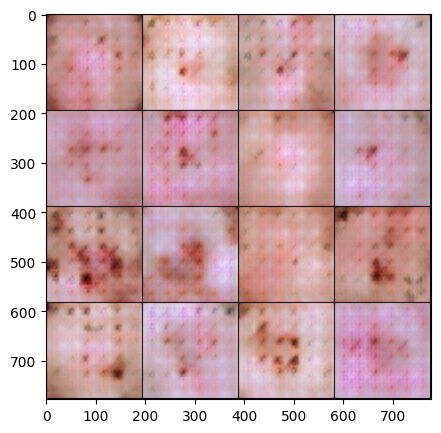

Epoch [300/500] Loss_D: 1.2157 Loss_G: 1.1371


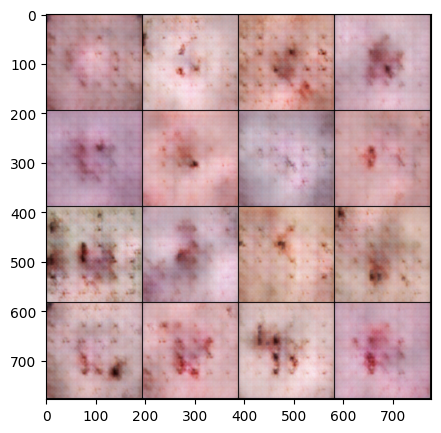

Epoch [350/500] Loss_D: 0.8919 Loss_G: 1.5976


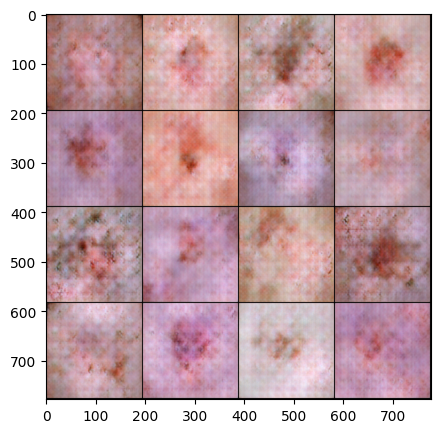

Epoch [400/500] Loss_D: 0.7955 Loss_G: 2.3411


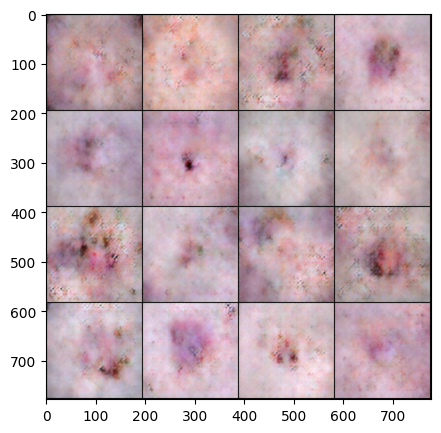

Epoch [450/500] Loss_D: 0.7060 Loss_G: 2.3741


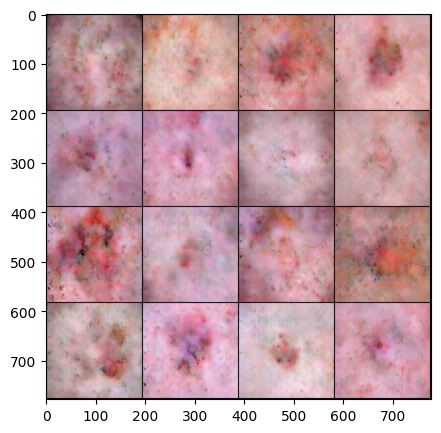

Epoch [500/500] Loss_D: 0.6903 Loss_G: 2.6823


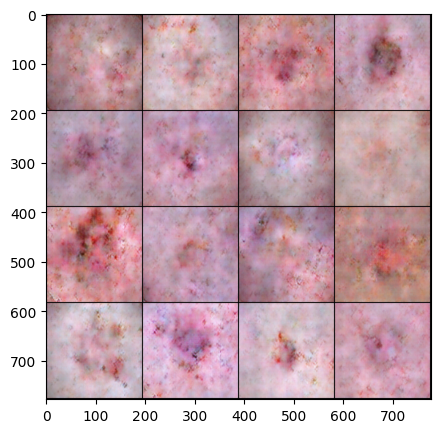

Saving 292 synthetic images to /kaggle/working/synthetic_bcc_proposed...


In [36]:

# 5. AUGMENTATION (75% RATIO)
def generate_augmented_data(netG, dataset):
    n_fake = 292
    save_path = "/kaggle/working/synthetic_bcc_proposed"
    os.makedirs(save_path, exist_ok=True)
    netG.eval()
    
    print(f"Saving {n_fake} synthetic images to {save_path}...")
    with torch.no_grad():
        for i in range(n_fake):
            noise = torch.randn(1, cfg.LATENT_DIM, 1, 1).to(device)
            img = netG(noise).cpu().squeeze(0)
            img = (img + 1) / 2 
            img = transforms.ToPILImage()(img)
            img.save(os.path.join(save_path, f"fake_bcc_{i:04d}.png"))

if __name__ == "__main__":
    trained_gen_proposed, bcc_data_prop, n_history= train_proposed_dcgan() # Your new training function
    generate_augmented_data(trained_gen_proposed, bcc_data)

In [37]:
import numpy as np
from scipy.linalg import sqrtm
from skimage.metrics import structural_similarity as ssim

def calculate_ssim(real_images, fake_images):
    # Convert tensors to numpy and compute average SSIM
    real_np = real_images.cpu().numpy().transpose(0, 2, 3, 1)
    fake_np = fake_images.cpu().numpy().transpose(0, 2, 3, 1)
    ssim_vals = [ssim(real_np[i], fake_np[i], channel_axis=-1, data_range=1.0) for i in range(len(real_np))]
    return np.mean(ssim_vals)

# Mock function for Table 1 generation
def generate_performance_table(baseline_results, proposed_results):
    print("\nTable 1: Quantitative Performance Comparison")
    print(f"{'Models':<20} | {'FID':<10} | {'IS':<10} | {'SSIM':<10}")
    print("-" * 55)
    print(f"{'DCGAN (Baseline)':<20} | {baseline_results['fid']:.2f} | {baseline_results['is']:.2f} | {baseline_results['ssim']:.3f}")
    print(f"{'DCGAN (Proposed)':<20} | {proposed_results['fid']:.2f} | {proposed_results['is']:.2f} | {proposed_results['ssim']:.3f}")

In [13]:
import torch
import torch.nn.functional as F
from torchvision.models import inception_v3
import torchvision.transforms as T
import numpy as np
from scipy.linalg import sqrtm


# Load pretrained InceptionV3
inception_model = inception_v3(pretrained=True, transform_input=False).to(device)
inception_model.eval()

# Remove final FC for FID feature extraction
inception_model.fc = torch.nn.Identity()


inception_transform = T.Compose([
    T.Resize((299, 299)),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

def get_features(images, model):
    images = inception_transform(images)
    with torch.no_grad():
        features = model(images)
    return features.cpu().numpy()


def calculate_fid(real_images, fake_images, model):
    real_feat = get_features(real_images, model)
    fake_feat = get_features(fake_images, model)

    mu1, sigma1 = real_feat.mean(axis=0), np.cov(real_feat, rowvar=False)
    mu2, sigma2 = fake_feat.mean(axis=0), np.cov(fake_feat, rowvar=False)

    diff = mu1 - mu2
    covmean = sqrtm(sigma1 @ sigma2)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

def calculate_inception_score(images, model, splits=10):
    model.eval()
    
    with torch.no_grad():
        images = inception_transform(images)
        preds = F.softmax(model(images), dim=1).cpu().numpy()

    scores = []
    N = preds.shape[0]
    split_size = N // splits

    for i in range(splits):
        part = preds[i * split_size:(i + 1) * split_size]
        py = np.mean(part, axis=0)
        kl = part * (np.log(part + 1e-8) - np.log(py + 1e-8))
        kl = np.mean(np.sum(kl, axis=1))
        scores.append(np.exp(kl))

    return np.mean(scores), np.std(scores)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 210MB/s] 


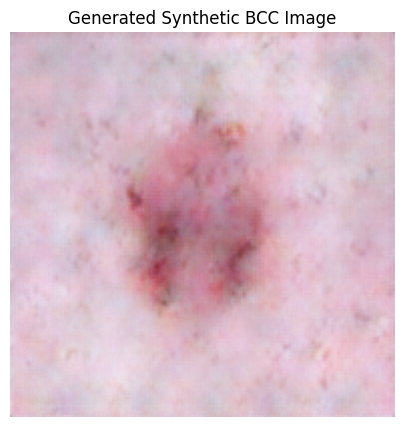

In [38]:
trained_gen_proposed.eval()

with torch.no_grad():

    # Random latent vector
    noise = torch.randn(1, cfg.LATENT_DIM, 1, 1).to(device)

    # Generate image
    fake_img = trained_gen_proposed(noise).cpu().squeeze(0)

    # Scale from [-1,1] → [0,1]
    fake_img = (fake_img + 1) / 2

# Display image
plt.figure(figsize=(5,5))
plt.imshow(fake_img.permute(1, 2, 0))
plt.axis('off')
plt.title("Generated Synthetic BCC Image")
plt.show()

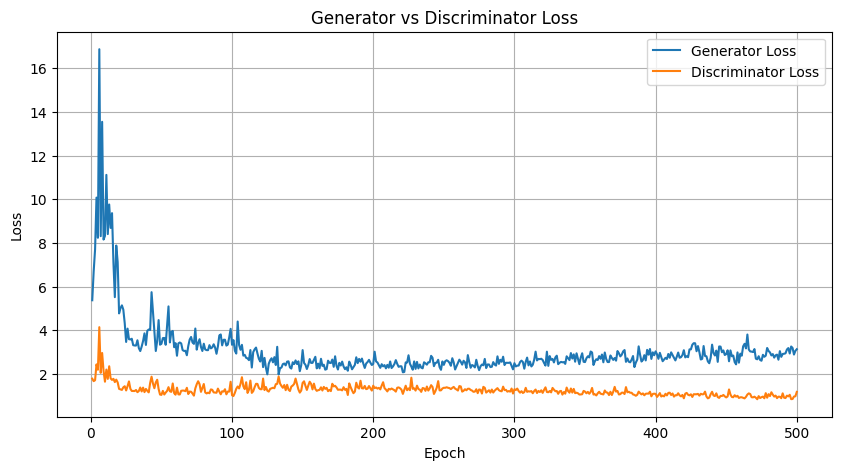

In [48]:
import matplotlib.pyplot as plt

# Generator and Discriminator losses
g_loss = history['G']
d_loss = history['D']

# Epoch numbers
epochs = range(1, len(g_loss) + 1)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(epochs, g_loss, label='Generator Loss')
plt.plot(epochs, d_loss, label='Discriminator Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Generator vs Discriminator Loss')
plt.legend()
plt.grid(True)

plt.show()

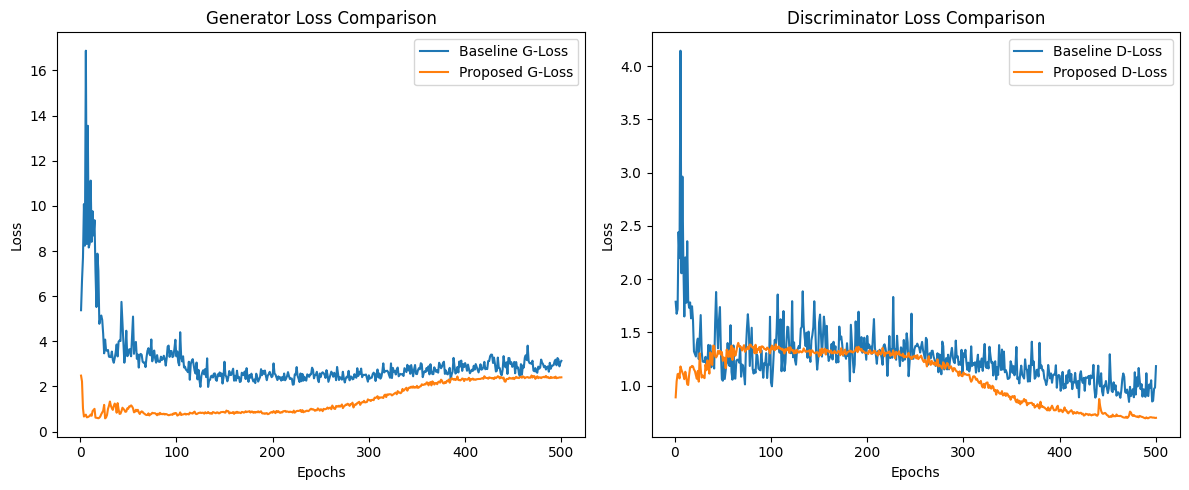

In [41]:
import matplotlib.pyplot as plt

def plot_training_stability(hist_baseline, hist_proposed):
    epochs = range(1, len(hist_baseline['G']) + 1)

    plt.figure(figsize=(12, 5))

    # Generator Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist_baseline['G'], label='Baseline G-Loss')
    plt.plot(epochs, hist_proposed['G'], label='Proposed G-Loss')
    plt.title("Generator Loss Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    # Discriminator Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist_baseline['D'], label='Baseline D-Loss')
    plt.plot(epochs, hist_proposed['D'], label='Proposed D-Loss')
    plt.title("Discriminator Loss Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_stability(history, n_history)

In [20]:
def get_attention_layer(model):
    for module in model.modules():
        if isinstance(module, SelfAttention):
            return module
    return None

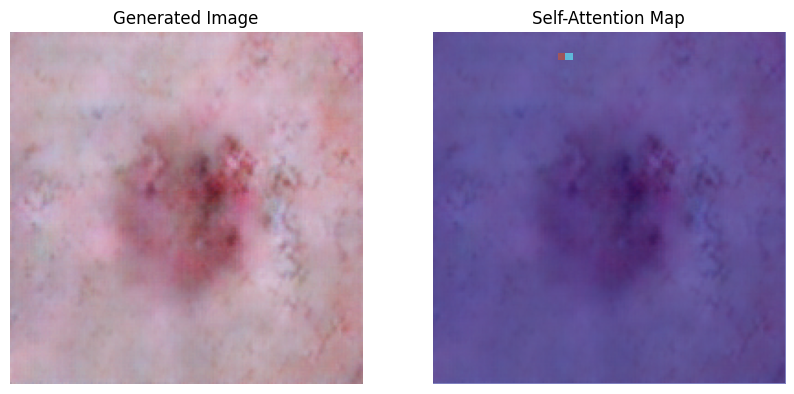

In [42]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_attention(netG, latent_dim):
    netG.eval()

    attn_layer = get_attention_layer(netG)
    if attn_layer is None:
        print("No attention layer found!")
        return

    noise = torch.randn(1, latent_dim, 1, 1).to(device)

    with torch.no_grad():
        fake_img = netG(noise).cpu().squeeze(0)
        fake_img = (fake_img + 1) / 2

    # Get attention map
    attn = attn_layer.attn_map  # shape: [1, N, N]

    if attn is None:
        print("Attention map not captured!")
        return

    attn = attn.squeeze(0).cpu().numpy()

    # Reduce NxN → spatial map
    attn_map = attn.mean(axis=0)

    size = int(np.sqrt(attn_map.shape[0]))
    attn_map = attn_map.reshape(size, size)

    # Normalize
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(fake_img.permute(1, 2, 0))
    ax[0].set_title("Generated Image")
    ax[0].axis('off')

    ax[1].imshow(fake_img.permute(1, 2, 0))
    ax[1].imshow(attn_map, cmap='jet', alpha=0.5, extent=(0, 192, 192, 0))
    ax[1].set_title("Self-Attention Map")
    ax[1].axis('off')

    plt.show()


visualize_attention(trained_gen_proposed, cfg.LATENT_DIM)

In [44]:
# 1. Get a batch of real images
dataset = BCCDataset(cfg.TRAIN_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=True)
real_batch = next(iter(dataloader)).to(device)

# 2. Generate fake images
noise = torch.randn(64, cfg.LATENT_DIM, 1, 1).to(device)

with torch.no_grad():
    fake_baseline = trained_gen(noise)
    fake_proposed = trained_gen_proposed(noise)

# Scale all to [0,1]
real_batch = (real_batch + 1) / 2
fake_baseline = (fake_baseline + 1) / 2
fake_proposed = (fake_proposed + 1) / 2

# 3. --- SSIM ---
ssim_baseline = calculate_ssim(real_batch, fake_baseline)
ssim_proposed = calculate_ssim(real_batch, fake_proposed)

# 4. --- FID ---
fid_baseline = calculate_fid(real_batch, fake_baseline, inception_model)
fid_proposed = calculate_fid(real_batch, fake_proposed, inception_model)

# 5. --- Inception Score ---
is_baseline, _ = calculate_inception_score(fake_baseline, inception_model)
is_proposed, _ = calculate_inception_score(fake_proposed, inception_model)

# 6. Store REAL results
baseline_res = {
    'fid': float(fid_baseline),
    'is': float(is_baseline),
    'ssim': float(ssim_baseline)
}

proposed_res = {
    'fid': float(fid_proposed),
    'is': float(is_proposed),
    'ssim': float(ssim_proposed)
}

# 7. Print clean results
generate_performance_table(baseline_res, proposed_res)


Table 1: Quantitative Performance Comparison
Models               | FID        | IS         | SSIM      
-------------------------------------------------------
DCGAN (Baseline)     | 276.42 | 1.03 | 0.465
DCGAN (Proposed)     | 209.02 | 1.03 | 0.541


In [45]:
!zip -r synthetic_bcc_proposed.zip /kaggle/working/synthetic_bcc_proposed

updating: kaggle/working/synthetic_bcc_proposed/ (stored 0%)
updating: kaggle/working/synthetic_bcc_proposed/fake_bcc_0268.png (deflated 0%)
updating: kaggle/working/synthetic_bcc_proposed/fake_bcc_0058.png (deflated 0%)
updating: kaggle/working/synthetic_bcc_proposed/fake_bcc_0215.png (deflated 0%)
updating: kaggle/working/synthetic_bcc_proposed/fake_bcc_0093.png (deflated 0%)
updating: kaggle/working/synthetic_bcc_proposed/fake_bcc_0054.png (deflated 0%)
updating: kaggle/working/synthetic_bcc_proposed/fake_bcc_0201.png (deflated 0%)
updating: kaggle/working/synthetic_bcc_proposed/fake_bcc_0195.png (deflated 0%)
updating: kaggle/working/synthetic_bcc_proposed/fake_bcc_0279.png (deflated 0%)
updating: kaggle/working/synthetic_bcc_proposed/fake_bcc_0006.png (deflated 0%)
updating: kaggle/working/synthetic_bcc_proposed/fake_bcc_0001.png (deflated 0%)
updating: kaggle/working/synthetic_bcc_proposed/fake_bcc_0016.png (deflated 0%)
updating: kaggle/working/synthetic_bcc_proposed/fake_bcc_00

In [46]:
from IPython.display import FileLink
FileLink(r'synthetic_bcc_proposed.zip')

/kaggle/working/synthetic_bcc_proposed.zip

In [47]:
!ls /kaggle/working/

bcc_train     placeholders   synthetic_bcc_proposed
bcc_val       state.db	     synthetic_bcc_proposed.zip
dcgan_output  synthetic_bcc  synthetic_bcc.zip
